In [1]:
#Crime and Incarceration Classification Project

In [2]:
# Research question

#**Can prior-year state-level crime and incarceration characteristics be 
#used to classify whether violent crime will decrease, remain stable, or increase in the following year?**

#Problem statement

#This project examines whether patterns observed in a state's crime and 
#incarceration data in one year can help classify the direction of violent 
#crime in the following year. The outcome is a three-category violent-crime 
#trend: **Decrease, Stable, or Increase**.

#Hypotheses
#**H0:** Prior-year state-level crime and incarceration characteristics do 
#not meaningfully distinguish among next-year violent-crime trend categories.

#**H1:** At least one prior-year crime or incarceration characteristic helps
#distinguish among next-year violent-crime trend categories.

#Working operational definition:  
#A change between **-2% and +2%** is classified as Stable. This threshold 
#is a project choice and can be tested later with a sensitivity analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
crime_incarceration = pd.read_csv("crime_and_incarceration_by_state.csv")
prison_custody = pd.read_csv("prison_custody_by_state.csv")
ucr = pd.read_csv("ucr_by_state.csv")

In [5]:
print("Crime and Incarceration Dataset:")
print(crime_incarceration.shape)
display(crime_incarceration.head())

print("\nPrison Custody Dataset:")
print(prison_custody.shape)
display(prison_custody.head())

print("\nUCR Dataset:")
print(ucr.shape)
display(ucr.head())

Crime and Incarceration Dataset:
(816, 17)


,jurisdiction,includes_jails,year,prisoner_count,crime_reporting_change,crimes_estimated,state_population,violent_crime_total,murder_manslaughter,rape_legacy,rape_revised,robbery,agg_assault,property_crime_total,burglary,larceny,vehicle_theft
0,FEDERAL,False,2001,149852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ALABAMA,False,2001,24741,False,False,4468912.0,19582.0,379.0,1369.0,NaN,5584.0,12250.0,173253.0,40642.0,119992.0,12619.0
2,ALASKA,True,2001,4570,False,False,633630.0,3735.0,39.0,501.0,NaN,514.0,2681.0,23160.0,3847.0,16695.0,2618.0
3,ARIZONA,False,2001,27710,False,False,5306966.0,28675.0,400.0,1518.0,NaN,8868.0,17889.0,293874.0,54821.0,186850.0,52203.0
4,ARKANSAS,False,2001,11489,False,False,2694698.0,12190.0,148.0,892.0,NaN,2181.0,8969.0,99106.0,22196.0,69590.0,7320.0



Prison Custody Dataset:
(51, 18)


,jurisdiction,includes_jails,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Federal,0,"149,852","158,216","168,144","177,600","186,364","190,844","197,285","198,414","205,087","206,968","214,774","216,915","214,989","209,561","195,622","188,311"
1,Alabama,0,"24,741","25,100","27,614","25,635","24,315","24,103","25,253","25,363","27,241","27,345","26,813","26,768","26,825","26,145","25,212","23,745"
2,Alaska,1,"4,570","4,351","4,472","4,534","4,798","5,052","5,151","4,997","5,472","5,369","6,216","6,308","5,081","6,323","5,247","4,378"
3,Arizona,0,"27,710","29,359","31,084","32,384","33,345","35,752","37,700","39,455","40,544","40,130","39,949","40,013","41,031","42,136","42,204","42,248"
4,Arkansas,0,"11,489","11,849","12,068","12,577","12,455","12,854","13,275","13,135","13,338","14,192","14,090","14,043","14,295","15,250","15,784","15,833"



UCR Dataset:
(948, 21)


,jurisdiction,year,crime_reporting_change,crimes_estimated,state_population,violent_crime_total,murder_manslaughter,rape_legacy,rape_revised,robbery,...,property_crime_total,burglary,larceny,vehicle_theft,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,Alaska,2001.0,0.0,0.0,"633,630","3,735",39,501,NaN,514,...,"23,160","3,847","16,695","2,618",NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,2002.0,0.0,0.0,"641,482","3,627",33,511,NaN,489,...,"24,118","3,908","17,739","2,471",NaN,NaN,NaN,NaN,NaN,NaN
2,Alaska,2003.0,0.0,0.0,"648,280","3,877",39,605,NaN,446,...,"24,386","3,874","18,051","2,461",NaN,NaN,NaN,NaN,NaN,NaN
3,Alaska,2004.0,0.0,0.0,"657,755","4,159",37,558,NaN,447,...,"22,172","3,773","16,159","2,240",NaN,NaN,NaN,NaN,NaN,NaN
4,Alaska,2005.0,0.0,0.0,"663,253","4,194",32,538,NaN,537,...,"23,975","4,131","17,249","2,595",NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#Viewed Variable Names

In [7]:
print(crime_incarceration.columns.tolist())
print(prison_custody.columns.tolist())
print(ucr.columns.tolist())

['jurisdiction', 'includes_jails', 'year', 'prisoner_count', 'crime_reporting_change', 'crimes_estimated', 'state_population', 'violent_crime_total', 'murder_manslaughter', 'rape_legacy', 'rape_revised', 'robbery', 'agg_assault', 'property_crime_total', 'burglary', 'larceny', 'vehicle_theft']
['jurisdiction', 'includes_jails', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016']
['jurisdiction', 'year', 'crime_reporting_change', 'crimes_estimated', 'state_population', 'violent_crime_total', 'murder_manslaughter', 'rape_legacy', 'rape_revised', 'robbery', 'agg_assault', 'property_crime_total', 'burglary', 'larceny', 'vehicle_theft', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20']


In [8]:
#Reviewing data types

crime_incarceration.info()

print(prison_custody.dtypes)
print(crime_incarceration.dtypes)
print(ucr.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   jurisdiction            816 non-null    object 
 1   includes_jails          816 non-null    bool   
 2   year                    816 non-null    int64  
 3   prisoner_count          816 non-null    int64  
 4   crime_reporting_change  799 non-null    object 
 5   crimes_estimated        799 non-null    object 
 6   state_population        799 non-null    float64
 7   violent_crime_total     799 non-null    float64
 8   murder_manslaughter     799 non-null    float64
 9   rape_legacy             749 non-null    float64
 10  rape_revised            199 non-null    float64
 11  robbery                 799 non-null    float64
 12  agg_assault             799 non-null    float64
 13  property_crime_total    799 non-null    float64
 14  burglary                799 non-null    fl

In [9]:
#Checking for exact duplicates and duplicate state-year combinations

print(
    "Duplicate state-year records:",
    crime_incarceration.duplicated(
        subset=[
            "jurisdiction",
            "year"
        ]
    ).sum()
)


print(
    ucr.duplicated(
        subset=[
            "jurisdiction",
            "year"
        ]
    ).sum()
)

Duplicate state-year records: 0
78


In [10]:
#Investigating "78" from UCR and verifying

ucr_duplicates = ucr[
    ucr.duplicated(
        subset=[
            "jurisdiction",
            "year"
        ],
        keep=False
    )
]

display(
    ucr_duplicates[
        [
            "jurisdiction",
            "year"
        ]
    ]
)


print(
    ucr[
        ucr["jurisdiction"].isna() &
        ucr["year"].isna()
    ].shape
)

,jurisdiction,year
869,NaN,NaN
870,NaN,NaN
871,NaN,NaN
872,NaN,NaN
873,NaN,NaN
...,...,...
943,NaN,NaN
944,NaN,NaN
945,NaN,NaN
946,NaN,NaN


(79, 21)


In [11]:
#Data Checking for missing values

missing_summary = pd.DataFrame({
    "Missing_Count":
        crime_incarceration.isnull().sum(),
        
    "Missing_Percent":
        crime_incarceration.isnull().mean() * 100
})

display(missing_summary)

,Missing_Count,Missing_Percent
jurisdiction,0,0.000000
includes_jails,0,0.000000
year,0,0.000000
prisoner_count,0,0.000000
crime_reporting_change,17,2.083333
crimes_estimated,17,2.083333
state_population,17,2.083333
violent_crime_total,17,2.083333
murder_manslaughter,17,2.083333
rape_legacy,67,8.210784


In [12]:
#Missing values are being shown: My study is examining differences across states, so I'm removing the 
#Federal category

df = crime_incarceration[
    crime_incarceration["jurisdiction"] != "FEDERAL"
].copy()

print(df.shape)

print(
    "Number of states:",
    df["jurisdiction"].nunique()
)

(800, 17)
Number of states: 50


In [13]:
#Ran missing value check again and locating it

state_missing = pd.DataFrame({
    "Missing_Count":
        df.isnull().sum(),
        
    "Missing_Percent":
        df.isnull().mean() * 100
})

display(
    state_missing[
        state_missing[
            "Missing_Count"
        ] > 0
    ]
)

display(
    df[
        df["state_population"].isna()
    ]
)

,Missing_Count,Missing_Percent
crime_reporting_change,1,0.125
crimes_estimated,1,0.125
state_population,1,0.125
violent_crime_total,1,0.125
murder_manslaughter,1,0.125
rape_legacy,51,6.375
rape_revised,601,75.125
robbery,1,0.125
agg_assault,1,0.125
property_crime_total,1,0.125


,jurisdiction,includes_jails,year,prisoner_count,crime_reporting_change,crimes_estimated,state_population,violent_crime_total,murder_manslaughter,rape_legacy,rape_revised,robbery,agg_assault,property_crime_total,burglary,larceny,vehicle_theft
746,NEW YORK,False,2015,51485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#Investigating the rape variables separately

rape_availability = (
    df.groupby("year")[
        [
            "rape_legacy",
            "rape_revised"
        ]
    ]
    .count()
)

display(rape_availability)

,rape_legacy,rape_revised
year,,
2001,50,0
2002,50,0
2003,50,0
2004,50,0
2005,50,0
2006,50,0
2007,50,0
2008,50,0
2009,50,0


In [15]:
#This demonstrates that the large amount of missing "rape_revised" data is
#largely structural because the revised definition was introduced later. 

#For this project I will use "rape_legacy"

In [16]:
#Checking for invalid or impossible values

#Checking population
print(
    "Population <= 0:",
    (df["state_population"] <= 0).sum()
)

#Checking Incarceration
print(
    "Negative prisoner counts:",
    (df["prisoner_count"] < 0).sum()
)


#Checking Crime Variables
crime_count_variables = [
    "violent_crime_total",
    "murder_manslaughter",
    "rape_legacy",
    "robbery",
    "agg_assault",
    "property_crime_total",
    "burglary",
    "larceny",
    "vehicle_theft"
]

for column in crime_count_variables:
    
    negative_count = (
        df[column] < 0
    ).sum()
    
    print(
        column,
        "negative values:",
        negative_count
    )


#Checking for Zero Values
for column in crime_count_variables:
    
    zero_count = (
        df[column] == 0
    ).sum()
    
    print(
        column,
        "zero values:",
        zero_count
    )

Population <= 0: 0
Negative prisoner counts: 0
violent_crime_total negative values: 0
murder_manslaughter negative values: 0
rape_legacy negative values: 0
robbery negative values: 0
agg_assault negative values: 0
property_crime_total negative values: 0
burglary negative values: 0
larceny negative values: 0
vehicle_theft negative values: 0
violent_crime_total zero values: 0
murder_manslaughter zero values: 0
rape_legacy zero values: 0
robbery zero values: 0
agg_assault zero values: 0
property_crime_total zero values: 0
burglary zero values: 0
larceny zero values: 0
vehicle_theft zero values: 0


In [17]:
#Examining categorical variables

#Checking non-numeric values
categorical_variables = [
    "includes_jails",
    "crime_reporting_change",
    "crimes_estimated"
]

for column in categorical_variables:
    
    print("\n", column)
    
    print(
        df[column].value_counts(
            dropna=False
        )
    )


#Confirming my study years
print(
    "First year:",
    df["year"].min()
)

print(
    "Last year:",
    df["year"].max()
)

print(
    "Number of years:",
    df["year"].nunique()
)


 includes_jails
includes_jails
False    704
True      96
Name: count, dtype: int64

 crime_reporting_change
crime_reporting_change
False    795
True       4
NaN        1
Name: count, dtype: int64

 crimes_estimated
crimes_estimated
False    782
True      17
NaN        1
Name: count, dtype: int64
First year: 2001
Last year: 2016
Number of years: 16


In [18]:
#Sorting observations by state amd year

df = df.sort_values(
    ["jurisdiction", "year"]
).reset_index(drop=True)

display(df.head())

,jurisdiction,includes_jails,year,prisoner_count,crime_reporting_change,crimes_estimated,state_population,violent_crime_total,murder_manslaughter,rape_legacy,rape_revised,robbery,agg_assault,property_crime_total,burglary,larceny,vehicle_theft
0,ALABAMA,False,2001,24741,False,False,4468912.0,19582.0,379.0,1369.0,NaN,5584.0,12250.0,173253.0,40642.0,119992.0,12619.0
1,ALABAMA,False,2002,25100,False,False,4478896.0,19931.0,303.0,1664.0,NaN,5962.0,12002.0,180400.0,42578.0,123932.0,13890.0
2,ALABAMA,False,2003,27614,False,False,4503726.0,19331.0,299.0,1656.0,NaN,6038.0,11338.0,182241.0,43245.0,124039.0,14957.0
3,ALABAMA,False,2004,25635,False,False,4525375.0,19324.0,254.0,1742.0,NaN,6042.0,11286.0,182340.0,44666.0,123650.0,14024.0
4,ALABAMA,False,2005,24315,False,False,4548327.0,19678.0,374.0,1564.0,NaN,6447.0,11293.0,177393.0,43473.0,120780.0,13140.0


In [19]:
#Creating crime rates per 100,000 people instead of raw counts because 
#states have a very different population size

df["incarceration_rate"] = (
    df["prisoner_count"] /
    df["state_population"]
) * 100000

In [20]:
#Created overall violent crime rate

df["violent_crime_rate"] = (
    df["violent_crime_total"] /
    df["state_population"]
) * 100000

In [21]:
#Created rates for individual violent crimes

df["murder_rate"] = (
    df["murder_manslaughter"] /
    df["state_population"]
) * 100000

df["rape_rate"] = (
    df["rape_legacy"] /
    df["state_population"]
) * 100000

df["robbery_rate"] = (
    df["robbery"] /
    df["state_population"]
) * 100000

df["aggravated_assault_rate"] = (
    df["agg_assault"] /
    df["state_population"]
) * 100000

In [22]:
#Additional: Created property crime rates because prior year property crime
#may help classify what happens to violent crime later.

df["property_crime_rate"] = (
    df["property_crime_total"] /
    df["state_population"]
) * 100000

df["burglary_rate"] = (
    df["burglary"] /
    df["state_population"]
) * 100000

df["larceny_rate"] = (
    df["larceny"] /
    df["state_population"]
) * 100000

df["vehicle_theft_rate"] = (
    df["vehicle_theft"] /
    df["state_population"]
) * 100000

In [23]:
#Newly created rates

rate_variables = [
    "jurisdiction",
    "year",
    "incarceration_rate",
    "violent_crime_rate",
    "murder_rate",
    "rape_rate",
    "robbery_rate",
    "aggravated_assault_rate",
    "property_crime_rate",
    "burglary_rate",
    "larceny_rate",
    "vehicle_theft_rate"
]

display(df[rate_variables].head(10))

,jurisdiction,year,incarceration_rate,violent_crime_rate,murder_rate,rape_rate,robbery_rate,aggravated_assault_rate,property_crime_rate,burglary_rate,larceny_rate,vehicle_theft_rate
0,ALABAMA,2001,553.624685,438.182717,8.480811,30.633855,124.952114,274.115937,3876.849667,909.438360,2685.038327,282.372980
1,ALABAMA,2002,560.405957,444.998053,6.765060,37.152012,133.113160,267.967821,4027.778274,950.636050,2767.021159,310.121066
2,ALABAMA,2003,613.136767,429.222382,6.638947,36.769555,134.066770,251.747109,4046.449540,960.204950,2754.141793,332.102797
3,ALABAMA,2004,566.472392,427.014336,5.612795,38.494047,133.513797,249.393697,4029.279341,987.012126,2732.370246,309.896970
4,ALABAMA,2005,534.592170,432.642596,8.222804,34.386270,141.744426,248.289096,3900.181319,955.801990,2655.481895,288.897434
5,ALABAMA,2006,524.088775,425.154870,8.306099,35.790156,153.554119,227.504496,3941.026695,973.683581,2640.795994,326.547120
6,ALABAMA,2007,545.674439,448.912465,8.902620,33.449651,159.858215,246.701979,3977.699368,980.563117,2689.477254,307.658998
7,ALABAMA,2008,544.048564,452.819666,7.529119,34.706879,157.575238,253.008430,4084.514897,1081.340226,2714.322487,288.852185
8,ALABAMA,2009,578.523875,450.102236,6.838394,31.940821,133.051359,278.271662,3780.378822,1037.312146,2507.524357,235.542319
9,ALABAMA,2010,571.425467,383.729598,5.746645,28.315286,101.642475,248.025192,3527.980205,887.783490,2414.928237,225.268478


In [24]:
#Most important: Created the following year violent crime rate

df["next_year"] = (
    df.groupby("jurisdiction")["year"]
      .shift(-1)
)

df["next_year_violent_crime_rate"] = (
    df.groupby("jurisdiction")["violent_crime_rate"]
      .shift(-1)
)

In [25]:
#Checking to make sure the next observation is actually the following year

df["consecutive_year"] = (
    df["next_year"] == df["year"] + 1
)

In [26]:
df["consecutive_year"].value_counts()

consecutive_year
True     750
False     50
Name: count, dtype: int64

In [27]:
#Calculating the percentage change in violent crimes
df["violent_crime_pct_change"] = (
    (
        df["next_year_violent_crime_rate"] -
        df["violent_crime_rate"]
    )
    /
    df["violent_crime_rate"]
) * 100



#Viewing a few observations
display(
    df[
        [
            "jurisdiction",
            "year",
            "violent_crime_rate",
            "next_year",
            "next_year_violent_crime_rate",
            "violent_crime_pct_change"
        ]
    ].head(20)
)

,jurisdiction,year,violent_crime_rate,next_year,next_year_violent_crime_rate,violent_crime_pct_change
0,ALABAMA,2001,438.182717,2002.0,444.998053,1.555364
1,ALABAMA,2002,444.998053,2003.0,429.222382,-3.545110
2,ALABAMA,2003,429.222382,2004.0,427.014336,-0.514429
3,ALABAMA,2004,427.014336,2005.0,432.642596,1.318049
4,ALABAMA,2005,432.642596,2006.0,425.154870,-1.730696
5,ALABAMA,2006,425.154870,2007.0,448.912465,5.587986
6,ALABAMA,2007,448.912465,2008.0,452.819666,0.870370
7,ALABAMA,2008,452.819666,2009.0,450.102236,-0.600113
8,ALABAMA,2009,450.102236,2010.0,383.729598,-14.746125
9,ALABAMA,2010,383.729598,2011.0,419.802364,9.400569


In [28]:
#Running my +2% sensitivity check

thresholds = [1, 2, 3, 5]

threshold_results = []

# Keep only rows where percent change actually exists
sensitivity_df = df[
    df["violent_crime_pct_change"].notna()
].copy()

for threshold in thresholds:
    
    # Temporary classification column
    temp_class = pd.Series(
        index=sensitivity_df.index,
        dtype="object"
    )
    
    # Decrease
    temp_class.loc[
        sensitivity_df["violent_crime_pct_change"] < -threshold
    ] = "Decrease"
    
    # Stable
    temp_class.loc[
        sensitivity_df["violent_crime_pct_change"].between(
            -threshold,
            threshold,
            inclusive="both"
        )
    ] = "Stable"
    
    # Increase
    temp_class.loc[
        sensitivity_df["violent_crime_pct_change"] > threshold
    ] = "Increase"
    
    counts = temp_class.value_counts()
    
    threshold_results.append({
        "Threshold": f"±{threshold}%",
        "Decrease": counts.get("Decrease", 0),
        "Stable": counts.get("Stable", 0),
        "Increase": counts.get("Increase", 0)
    })

threshold_comparison = pd.DataFrame(
    threshold_results
)

display(threshold_comparison)

,Threshold,Decrease,Stable,Increase
0,±1%,363,121,264
1,±2%,301,225,222
2,±3%,255,305,188
3,±5%,151,464,133


In [29]:
#Stable violent crime was operationally defined in this study as a year-to-year change between −2% and +2%. This threshold was not treated as an established 
#crime-science standard, but as an analytical definition selected for this project. A sensitivity analysis using ±1%, ±2%, ±3%, and ±5% thresholds showed that the 
#size of the Stable category changed substantially as the cutoff widened. The ±2% threshold was retained because it provided a moderate definition of stability 
#that separated relatively small annual fluctuations from larger increases or decreases without classifying most observations as Stable. The alternative thresholds 
#were reviewed to confirm that the final classification structure was influenced by the chosen cutoff and should therefore be interpreted as study-specific.

In [30]:
#Created the three-category outcome while preserving missing values

df["violent_crime_trend"] = pd.Series(
    pd.NA,
    index=df.index,
    dtype="object"
)

df.loc[
    df[
        "violent_crime_pct_change"
    ] < -2,
    "violent_crime_trend"
] = "Decrease"

df.loc[
    df[
        "violent_crime_pct_change"
    ].between(
        -2,
        2,
        inclusive="both"
    ),
    "violent_crime_trend"
] = "Stable"

df.loc[
    df[
        "violent_crime_pct_change"
    ] > 2,
    "violent_crime_trend"
] = "Increase"

In [31]:
#Defined Predictors

predictor_variables = [
    "incarceration_rate",
    "violent_crime_rate",
    "murder_rate",
    "rape_rate",
    "robbery_rate",
    "aggravated_assault_rate",
    "property_crime_rate",
    "burglary_rate",
    "larceny_rate",
    "vehicle_theft_rate"
]

outcome_variable = (
    "violent_crime_trend"
)

In [32]:
#Creating the candidate modeling data set, removing only the rows that
#cannot possibly have a next year, not missing value rows

candidate_df = df[
    df["consecutive_year"] == True
].copy()


pre_model_df = candidate_df[
    [
        "jurisdiction",
        "year"
    ]
    +
    predictor_variables
    +
    [
        "next_year",
        "next_year_violent_crime_rate",
        "violent_crime_pct_change",
        "violent_crime_trend"
    ]
].copy()

In [33]:
#Checking 

print(
    "Candidate sample:",
    pre_model_df.shape
)

Candidate sample: (750, 16)


In [34]:
#Validating the derived variables

for column in predictor_variables:
    
    values = (
        pre_model_df[column]
        .to_numpy()
    )
    
    print(
        column,
        "infinite values:",
        np.isinf(values).sum()
    )


#Checking negative rates
for column in predictor_variables:
    
    values = (
        pre_model_df[column]
        .to_numpy()
    )
    
    print(
        column,
        "negative values:",
        np.sum(values < 0)
    )

incarceration_rate infinite values: 0
violent_crime_rate infinite values: 0
murder_rate infinite values: 0
rape_rate infinite values: 0
robbery_rate infinite values: 0
aggravated_assault_rate infinite values: 0
property_crime_rate infinite values: 0
burglary_rate infinite values: 0
larceny_rate infinite values: 0
vehicle_theft_rate infinite values: 0
incarceration_rate negative values: 0
violent_crime_rate negative values: 0
murder_rate negative values: 0
rape_rate negative values: 0
robbery_rate negative values: 0
aggravated_assault_rate negative values: 0
property_crime_rate negative values: 0
burglary_rate negative values: 0
larceny_rate negative values: 0
vehicle_theft_rate negative values: 0


In [35]:
#Investigating missingness after the derived variables were created

derived_missing = pd.DataFrame({
    "Missing_Count":
        pre_model_df.isnull().sum(),
        
    "Missing_Percent":
        pre_model_df.isnull().mean() * 100
})

display(
    derived_missing[
        derived_missing[
            "Missing_Count"
        ] > 0
    ]
)


#Displaying
missing_model_rows = pre_model_df[
    pre_model_df.isnull().any(
        axis=1
    )
]

display(missing_model_rows)

,Missing_Count,Missing_Percent
incarceration_rate,1,0.133333
violent_crime_rate,1,0.133333
murder_rate,1,0.133333
rape_rate,1,0.133333
robbery_rate,1,0.133333
aggravated_assault_rate,1,0.133333
property_crime_rate,1,0.133333
burglary_rate,1,0.133333
larceny_rate,1,0.133333
vehicle_theft_rate,1,0.133333


,jurisdiction,year,incarceration_rate,violent_crime_rate,murder_rate,rape_rate,robbery_rate,aggravated_assault_rate,property_crime_rate,burglary_rate,larceny_rate,vehicle_theft_rate,next_year,next_year_violent_crime_rate,violent_crime_pct_change,violent_crime_trend
509,NEW YORK,2014,265.174709,381.83497,3.124648,19.841765,121.770098,229.426108,1718.211788,257.168116,1381.352498,79.691173,2015.0,NaN,NaN,<NA>
510,NEW YORK,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.0,374.641705,NaN,<NA>


In [36]:
#Generating descriptive statistics

descriptive_statistics = (
    pre_model_df[
        predictor_variables
        +
        [
            "violent_crime_pct_change"
        ]
    ]
    .describe()
    .T
)

display(
    descriptive_statistics
)

,count,mean,std,min,25%,50%,75%,max
incarceration_rate,749.0,396.707810,144.569020,128.517505,301.903102,390.791985,478.360328,863.746342
violent_crime_rate,749.0,387.266048,161.672138,78.244422,265.363163,352.006115,498.977730,822.682558
murder_rate,749.0,4.533343,2.294789,0.788754,2.594187,4.431283,6.057729,14.557892
rape_rate,749.0,32.693791,11.535187,9.661671,25.400211,30.987091,38.845655,93.323872
robbery_rate,749.0,97.710045,54.450057,6.757734,59.989993,93.533159,134.301666,282.024372
aggravated_assault_rate,749.0,250.086103,119.151484,42.592730,157.255426,222.938249,328.340583,626.984456
property_crime_rate,749.0,3083.883207,788.922715,1406.614892,2468.246782,3019.383715,3662.286139,5849.819660
burglary_rate,749.0,660.129347,233.593327,254.563018,471.446696,612.080877,841.748083,1241.624376
larceny_rate,749.0,2143.166312,496.705228,1063.826389,1733.267576,2134.444716,2469.079554,3977.228305
vehicle_theft_rate,749.0,280.587548,162.708872,28.432597,170.192611,247.403713,352.925941,1116.402970


In [37]:
#Performing meaningful NumPy analysis

numpy_summary = []

for column in predictor_variables:
    
    values = (
        pre_model_df[column]
        .dropna()
        .to_numpy()
    )
    
    numpy_summary.append({
        "Variable":
            column,
            
        "Mean":
            np.mean(values),
            
        "Median":
            np.median(values),
            
        "Std_Dev":
            np.std(
                values,
                ddof=1
            ),
            
        "Minimum":
            np.min(values),
            
        "25th_Percentile":
            np.percentile(
                values,
                25
            ),
            
        "75th_Percentile":
            np.percentile(
                values,
                75
            ),
            
        "Maximum":
            np.max(values)
    })

numpy_summary_df = pd.DataFrame(
    numpy_summary
)

display(
    numpy_summary_df
)

,Variable,Mean,Median,Std_Dev,Minimum,25th_Percentile,75th_Percentile,Maximum
0,incarceration_rate,396.707810,390.791985,144.569020,128.517505,301.903102,478.360328,863.746342
1,violent_crime_rate,387.266048,352.006115,161.672138,78.244422,265.363163,498.977730,822.682558
2,murder_rate,4.533343,4.431283,2.294789,0.788754,2.594187,6.057729,14.557892
3,rape_rate,32.693791,30.987091,11.535187,9.661671,25.400211,38.845655,93.323872
4,robbery_rate,97.710045,93.533159,54.450057,6.757734,59.989993,134.301666,282.024372
5,aggravated_assault_rate,250.086103,222.938249,119.151484,42.592730,157.255426,328.340583,626.984456
6,property_crime_rate,3083.883207,3019.383715,788.922715,1406.614892,2468.246782,3662.286139,5849.819660
7,burglary_rate,660.129347,612.080877,233.593327,254.563018,471.446696,841.748083,1241.624376
8,larceny_rate,2143.166312,2134.444716,496.705228,1063.826389,1733.267576,2469.079554,3977.228305
9,vehicle_theft_rate,280.587548,247.403713,162.708872,28.432597,170.192611,352.925941,1116.402970


In [38]:
#Examining my actual outcome change distribution

change_values = (
    pre_model_df[
        "violent_crime_pct_change"
    ]
    .dropna()
    .to_numpy()
)

print(
    "Mean:",
    np.mean(change_values)
)

print(
    "Median:",
    np.median(change_values)
)

print(
    "Minimum:",
    np.min(change_values)
)

print(
    "Maximum:",
    np.max(change_values)
)

Mean: -0.14979082362301632
Median: -0.8270401404729468
Minimum: -21.010891438285242
Maximum: 77.40923680340424


In [39]:
#Examining percentiles

percentiles = np.percentile(
    change_values,
    [
        1,
        5,
        25,
        50,
        75,
        95,
        99
    ]
)

percentile_table = pd.DataFrame({
    "Percentile": [
        "1%",
        "5%",
        "25%",
        "50%",
        "75%",
        "95%",
        "99%"
    ],
    "Violent_Crime_Change":
        percentiles
})

display(
    percentile_table
)

,Percentile,Violent_Crime_Change
0,1%,-14.772867
1,5%,-9.946671
2,25%,-4.201059
3,50%,-0.827040
4,75%,3.010889
5,95%,11.265314
6,99%,21.977756


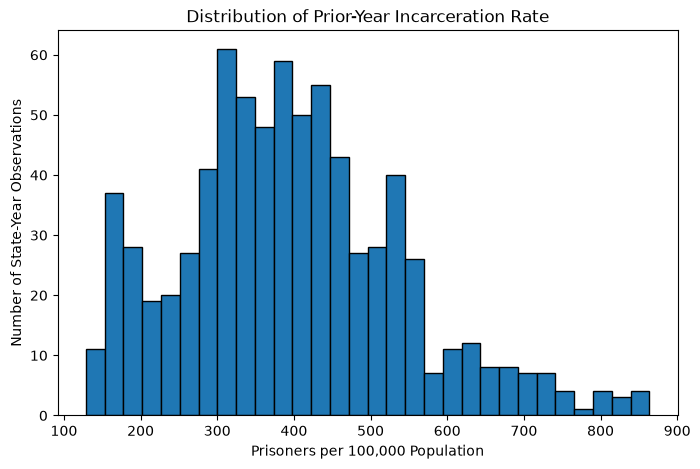

In [40]:
#Examining distributions

#Incarceration rate
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    pre_model_df[
        "incarceration_rate"
    ].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Prior-Year Incarceration Rate"
)

plt.xlabel(
    "Prisoners per 100,000 Population"
)

plt.ylabel(
    "Number of State-Year Observations"
)

plt.show()

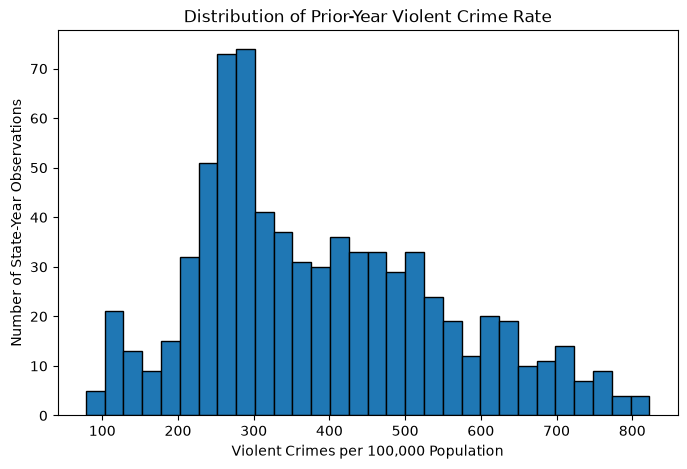

In [41]:
#Prior-year violent crime rate

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    pre_model_df[
        "violent_crime_rate"
    ].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Prior-Year Violent Crime Rate"
)

plt.xlabel(
    "Violent Crimes per 100,000 Population"
)

plt.ylabel(
    "Number of State-Year Observations"
)

plt.show()

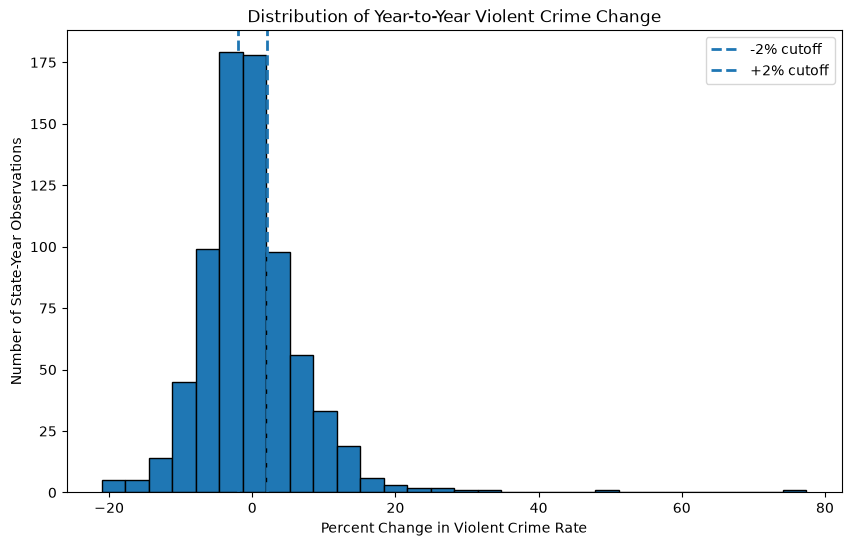

In [42]:
#Percentage-change distribution

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    pre_model_df[
        "violent_crime_pct_change"
    ].dropna(),
    bins=30,
    edgecolor="black"
)

plt.axvline(
    -2,
    linestyle="--",
    linewidth=2,
    label="-2% cutoff"
)

plt.axvline(
    2,
    linestyle="--",
    linewidth=2,
    label="+2% cutoff"
)

plt.title(
    "Distribution of Year-to-Year Violent Crime Change"
)

plt.xlabel(
    "Percent Change in Violent Crime Rate"
)

plt.ylabel(
    "Number of State-Year Observations"
)

plt.legend()

plt.show()

In [43]:
#Examining the classification outcome

print(
    pre_model_df[
        "violent_crime_trend"
    ].value_counts(
        dropna=False
    )
)

violent_crime_trend
Decrease    301
Stable      225
Increase    222
<NA>          2
Name: count, dtype: int64


In [44]:
#Calculating percentages

trend_summary = pd.DataFrame({
    "Count":
        pre_model_df[
            "violent_crime_trend"
        ].value_counts(
            dropna=False
        ),
        
    "Percent":
        pre_model_df[
            "violent_crime_trend"
        ].value_counts(
            normalize=True,
            dropna=False
        ) * 100
})

display(
    trend_summary
)

,Count,Percent
violent_crime_trend,,
Decrease,301,40.133333
Stable,225,30.000000
Increase,222,29.600000
<NA>,2,0.266667


In [45]:
#Identify potential outliers

outlier_summary = []

for column in predictor_variables:
    
    values = (
        pre_model_df[column]
        .dropna()
    )
    
    Q1 = values.quantile(
        0.25
    )
    
    Q3 = values.quantile(
        0.75
    )
    
    IQR = Q3 - Q1
    
    lower_bound = (
        Q1 - 1.5 * IQR
    )
    
    upper_bound = (
        Q3 + 1.5 * IQR
    )
    
    outliers = values[
        (values < lower_bound) |
        (values > upper_bound)
    ]
    
    outlier_summary.append({
        "Variable":
            column,
            
        "Lower_Bound":
            lower_bound,
            
        "Upper_Bound":
            upper_bound,
            
        "Outlier_Count":
            len(outliers)
    })

outlier_summary_df = pd.DataFrame(
    outlier_summary
)

display(
    outlier_summary_df
)

,Variable,Lower_Bound,Upper_Bound,Outlier_Count
0,incarceration_rate,37.217263,743.046167,16
1,violent_crime_rate,-85.058687,849.399580,0
2,murder_rate,-2.601125,11.253041,7
3,rape_rate,5.232044,59.013822,20
4,robbery_rate,-51.477516,245.769175,7
5,aggravated_assault_rate,-99.372310,584.968319,5
6,property_crime_rate,677.187745,5453.345175,4
7,burglary_rate,-84.005386,1397.200165,0
8,larceny_rate,629.549609,3572.797521,4
9,vehicle_theft_rate,-103.907384,627.025936,31


In [46]:
#Inspecting extreme observations


#Largest violent-crime increases
largest_increases = (
    pre_model_df[
        [
            "jurisdiction",
            "year",
            "violent_crime_rate",
            "next_year_violent_crime_rate",
            "violent_crime_pct_change"
        ]
    ]
    .sort_values(
        "violent_crime_pct_change",
        ascending=False
    )
    .head(10)
)

display(
    largest_increases
)

,jurisdiction,year,violent_crime_rate,next_year_violent_crime_rate,violent_crime_pct_change
532,NORTH DAKOTA,2005,111.250305,197.368318,77.409237
644,SOUTH DAKOTA,2005,178.994764,264.861194,47.971476
404,MONTANA,2005,281.790493,377.289781,33.890174
457,NEW HAMPSHIRE,2010,167.374566,217.330762,29.846946
531,NORTH DAKOTA,2004,87.693381,111.250305,26.862830
650,SOUTH DAKOTA,2011,255.587408,323.842661,26.705249
436,NEVADA,2005,607.469798,748.819188,23.268546
648,SOUTH DAKOTA,2009,218.739191,268.920570,22.941193
276,LOUISIANA,2005,596.561468,721.191072,20.891326
717,VERMONT,2014,99.271900,118.043198,18.908975


In [47]:
#Largest decreases

largest_decreases = (
    pre_model_df[
        [
            "jurisdiction",
            "year",
            "violent_crime_rate",
            "next_year_violent_crime_rate",
            "violent_crime_pct_change"
        ]
    ]
    .sort_values(
        "violent_crime_pct_change"
    )
    .head(10)
)

display(
    largest_decreases
)

,jurisdiction,year,violent_crime_rate,next_year_violent_crime_rate,violent_crime_pct_change
647,SOUTH DAKOTA,2008,276.923230,218.739191,-21.010891
451,NEW HAMPSHIRE,2004,169.492961,134.754698,-20.495401
716,VERMONT,2013,123.633057,99.271900,-19.704404
402,MONTANA,2003,364.970261,293.768610,-19.508891
406,MONTANA,2007,379.804585,311.440503,-17.999804
174,HAWAII,2015,293.447276,241.621129,-17.661144
752,WEST VIRGINIA,2001,279.570788,233.865445,-16.348397
620,RHODE ISLAND,2013,257.273433,219.205761,-14.796581
8,ALABAMA,2009,450.102236,383.729598,-14.746125
141,FLORIDA,2014,540.488588,461.865442,-14.546680


In [48]:
#Examining relationships and correlations

correlation_matrix = (
    pre_model_df[
        predictor_variables
    ]
    .corr()
)

display(
    correlation_matrix.round(2)
)

,incarceration_rate,violent_crime_rate,murder_rate,rape_rate,robbery_rate,aggravated_assault_rate,property_crime_rate,burglary_rate,larceny_rate,vehicle_theft_rate
incarceration_rate,1.00,0.53,0.49,0.33,0.41,0.49,0.38,0.42,0.31,0.28
violent_crime_rate,0.53,1.00,0.74,0.35,0.75,0.97,0.56,0.60,0.44,0.52
murder_rate,0.49,0.74,1.00,0.11,0.67,0.67,0.49,0.63,0.34,0.42
rape_rate,0.33,0.35,0.11,1.00,-0.08,0.41,0.28,0.21,0.28,0.20
robbery_rate,0.41,0.75,0.67,-0.08,1.00,0.56,0.44,0.49,0.28,0.57
aggravated_assault_rate,0.49,0.97,0.67,0.41,0.56,1.00,0.54,0.57,0.44,0.43
property_crime_rate,0.38,0.56,0.49,0.28,0.44,0.54,1.00,0.83,0.96,0.74
burglary_rate,0.42,0.60,0.63,0.21,0.49,0.57,0.83,1.00,0.68,0.52
larceny_rate,0.31,0.44,0.34,0.28,0.28,0.44,0.96,0.68,1.00,0.61
vehicle_theft_rate,0.28,0.52,0.42,0.20,0.57,0.43,0.74,0.52,0.61,1.00


In [49]:
#Identifying very strong relationships
high_correlations = []

for i in range(
    len(predictor_variables)
):
    
    for j in range(
        i + 1,
        len(predictor_variables)
    ):
        
        correlation = (
            correlation_matrix.iloc[
                i,
                j
            ]
        )
        
        if abs(correlation) >= 0.80:
            
            high_correlations.append({
                "Variable_1":
                    predictor_variables[i],
                    
                "Variable_2":
                    predictor_variables[j],
                    
                "Correlation":
                    correlation
            })

high_correlation_df = pd.DataFrame(
    high_correlations
)

display(
    high_correlation_df
)

,Variable_1,Variable_2,Correlation
0,violent_crime_rate,aggravated_assault_rate,0.965341
1,property_crime_rate,burglary_rate,0.829339
2,property_crime_rate,larceny_rate,0.955517


In [50]:
#Overall crime total are partially constructed from these crime components.
#This is something I need to address later before multinomial logistic
#regression because it may contribute to multicollinearity.

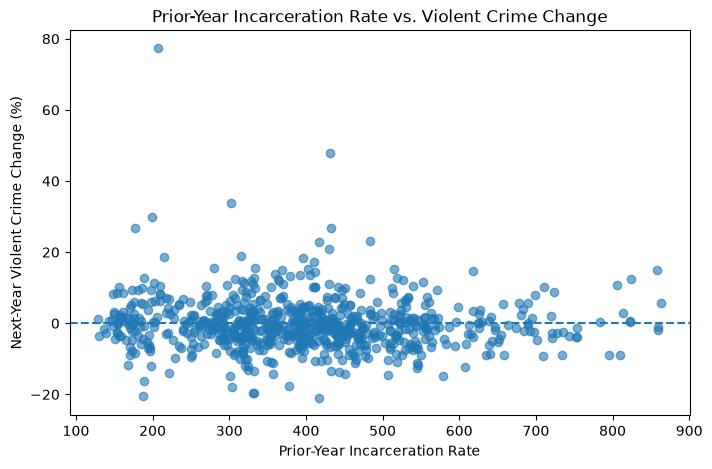

In [51]:
#Visualizing important relationships

#Examining prior incarceration and subsequent crime change
plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    pre_model_df[
        "incarceration_rate"
    ],
    pre_model_df[
        "violent_crime_pct_change"
    ],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Prior-Year Incarceration Rate"
)

plt.ylabel(
    "Next-Year Violent Crime Change (%)"
)

plt.title(
    "Prior-Year Incarceration Rate vs. Violent Crime Change"
)

plt.show()

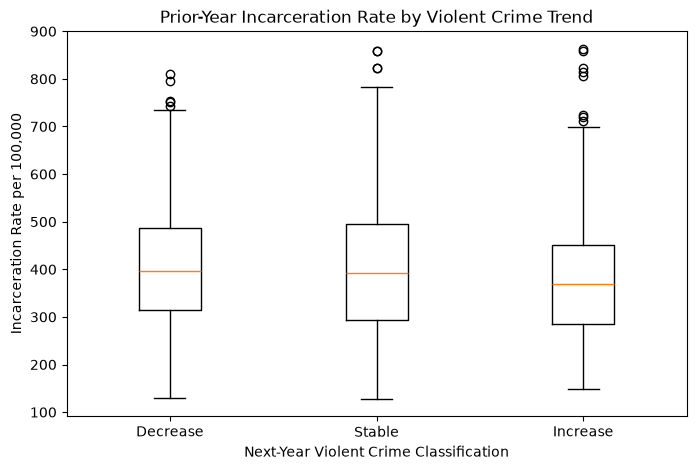

In [52]:
#Comparing incarceration distributions across the three outcome classes
plot_data = (
    pre_model_df.dropna(
        subset=[
            "violent_crime_trend",
            "incarceration_rate"
        ]
    )
)

groups = [
    plot_data.loc[
        plot_data[
            "violent_crime_trend"
        ] == category,
        "incarceration_rate"
    ]
    for category in [
        "Decrease",
        "Stable",
        "Increase"
    ]
]

plt.figure(
    figsize=(8, 5)
)

plt.boxplot(
    groups,
    tick_labels=[
        "Decrease",
        "Stable",
        "Increase"
    ]
)

plt.title(
    "Prior-Year Incarceration Rate by Violent Crime Trend"
)

plt.xlabel(
    "Next-Year Violent Crime Classification"
)

plt.ylabel(
    "Incarceration Rate per 100,000"
)

plt.show()

In [53]:
#Evaluating my imputation options

required_variables = (
    predictor_variables
    +
    [
        outcome_variable
    ]
)

incomplete_rows = pre_model_df[
    pre_model_df[
        required_variables
    ]
    .isnull()
    .any(axis=1)
]

display(
    incomplete_rows
)

,jurisdiction,year,incarceration_rate,violent_crime_rate,murder_rate,rape_rate,robbery_rate,aggravated_assault_rate,property_crime_rate,burglary_rate,larceny_rate,vehicle_theft_rate,next_year,next_year_violent_crime_rate,violent_crime_pct_change,violent_crime_trend
509,NEW YORK,2014,265.174709,381.83497,3.124648,19.841765,121.770098,229.426108,1718.211788,257.168116,1381.352498,79.691173,2015.0,NaN,NaN,<NA>
510,NEW YORK,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.0,374.641705,NaN,<NA>


In [54]:
#Counting them

number_incomplete = len(
    incomplete_rows
)

percent_incomplete = (
    number_incomplete /
    len(pre_model_df)
) * 100

print(
    "Incomplete observations:",
    number_incomplete
)

print(
    "Percent incomplete:",
    round(
        percent_incomplete,
        2
    ),
    "%"
)

Incomplete observations: 2
Percent incomplete: 0.27 %


In [55]:
#For New York 2014, the problem is that the outcome is missing because 2015 
#crime data are unavailable. We should not impute the dependent variable.

#For New York 2015, almost the entire crime profile required to construct 
#both predictors and the outcome is missing. KNN would be creating a largely
#artificial state-year record

#Mean, median, KNN, and complete-case approaches were considered. Imputation
#was not selected because the missingness involved an unavailable outcome 
#for one transition and a block of missing crime information for another. 
#Because only 0.27% of candidate observations were affected, the incomplete 
#observations were excluded rather than estimated.

In [56]:
#Missing data decision

model_df = (
    pre_model_df
    .dropna(
        subset=
        predictor_variables
        +
        [
            outcome_variable
        ]
    )
    .copy()
)

In [57]:
#Documented observations removed

before_cleaning = len(
    pre_model_df
)

after_cleaning = len(
    model_df
)

removed = (
    before_cleaning -
    after_cleaning
)

percent_removed = (
    removed /
    before_cleaning
) * 100

print(
    "Before cleaning:",
    before_cleaning
)

print(
    "After cleaning:",
    after_cleaning
)

print(
    "Observations removed:",
    removed
)

print(
    "Percent removed:",
    round(
        percent_removed,
        2
    ),
    "%"
)


print(
    model_df.shape
)

Before cleaning: 750
After cleaning: 748
Observations removed: 2
Percent removed: 0.27 %
(748, 16)


In [58]:
#Missing values
print(
    model_df.isnull().sum()
)


#Duplicates
print(
    "Duplicate rows:",
    model_df.duplicated().sum()
)

print(
    "Duplicate state-year observations:",
    model_df.duplicated(
        subset=[
            "jurisdiction",
            "year"
        ]
    ).sum()
)


#Outcome distributions
print(
    model_df[
        "violent_crime_trend"
    ].value_counts()
)

jurisdiction                    0
year                            0
incarceration_rate              0
violent_crime_rate              0
murder_rate                     0
rape_rate                       0
robbery_rate                    0
aggravated_assault_rate         0
property_crime_rate             0
burglary_rate                   0
larceny_rate                    0
vehicle_theft_rate              0
next_year                       0
next_year_violent_crime_rate    0
violent_crime_pct_change        0
violent_crime_trend             0
dtype: int64
Duplicate rows: 0
Duplicate state-year observations: 0
violent_crime_trend
Decrease    301
Stable      225
Increase    222
Name: count, dtype: int64


In [59]:
#Percentages
print(
    model_df[
        "violent_crime_trend"
    ].value_counts(
        normalize=True
    ) * 100
)


display(
    model_df[
        predictor_variables
    ]
    .describe()
    .T
)

violent_crime_trend
Decrease    40.240642
Stable      30.080214
Increase    29.679144
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
incarceration_rate,748.0,396.883656,144.585576,128.517505,303.248908,390.880863,478.400755,863.746342
violent_crime_rate,748.0,387.273309,161.780194,78.244422,265.284972,351.884444,499.174031,822.682558
murder_rate,748.0,4.535226,2.295745,0.788754,2.591113,4.432939,6.060771,14.557892
rape_rate,748.0,32.710973,11.533311,9.661671,25.404680,30.990249,38.845957,93.323872
robbery_rate,748.0,97.677880,54.479370,6.757734,59.863269,93.516288,134.355007,282.024372
aggravated_assault_rate,748.0,250.113723,119.228811,42.592730,157.249004,222.779741,328.427691,626.984456
property_crime_rate,748.0,3085.708971,787.865585,1406.614892,2470.010707,3019.506796,3662.379639,5849.819660
burglary_rate,748.0,660.668065,233.283572,254.563018,471.610000,612.300333,842.046422,1241.624376
larceny_rate,748.0,2144.184779,496.254370,1063.826389,1735.132501,2135.162468,2469.222096,3977.228305
vehicle_theft_rate,748.0,280.856126,162.651519,28.432597,170.503537,247.474394,353.450989,1116.402970


In [60]:
#Defining X and Y - the predictors and target can officially be separated
#for modeling 

X = model_df[
    predictor_variables
].copy()

y = model_df[
    outcome_variable
].copy()

In [61]:
#Checking
print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "\nTarget distribution:"
)

print(
    y.value_counts()
)

X shape: (748, 10)
y shape: (748,)

Target distribution:
violent_crime_trend
Decrease    301
Stable      225
Increase    222
Name: count, dtype: int64


In [62]:
#Saved analysis-ready data set

model_df.to_csv(
    "violent_crime_classification_ready.csv",
    index=False
)


print(
    "Analysis-ready dataset saved."
)

Analysis-ready dataset saved.


In [63]:
#Confirming the classification target


class_order = [
    "Decrease",
    "Stable",
    "Increase"
]

class_counts = (
    model_df["violent_crime_trend"]
    .value_counts()
    .reindex(class_order)
)

class_percent = (
    model_df["violent_crime_trend"]
    .value_counts(normalize=True)
    .reindex(class_order) * 100
)

classification_summary = pd.DataFrame({
    "Count": class_counts,
    "Percent": class_percent
})

display(classification_summary)

,Count,Percent
violent_crime_trend,,
Decrease,301,40.240642
Stable,225,30.080214
Increase,222,29.679144


In [64]:
#Quantifying class imbalance

imbalance_ratio = (
    class_counts.max() /
    class_counts.min()
)

print(
    "Largest-to-smallest class ratio:",
    round(imbalance_ratio, 2)
)

Largest-to-smallest class ratio: 1.36


In [65]:
#This is mild imbalance. Other oversampling is not needed.

#Confirming the target is complete
print(
    "Missing target values:",
    model_df[
        "violent_crime_trend"
    ].isnull().sum()
)

print(
    "Target categories:",
    model_df[
        "violent_crime_trend"
    ].unique()
)

Missing target values: 0
Target categories: ['Stable' 'Decrease' 'Increase']


In [66]:
#Featuring Preparation/Modeling Readiness, defining the final predictors

predictor_variables = [
    "incarceration_rate",
    "violent_crime_rate",
    "murder_rate",
    "rape_rate",
    "robbery_rate",
    "aggravated_assault_rate",
    "property_crime_rate",
    "burglary_rate",
    "larceny_rate",
    "vehicle_theft_rate"
]

In [67]:
#Defining the final predictors

final_predictors = [
    "incarceration_rate",
    "murder_rate",
    "rape_rate",
    "robbery_rate",
    "aggravated_assault_rate",
    "burglary_rate",
    "larceny_rate",
    "vehicle_theft_rate"
]

outcome_variable = (
    "violent_crime_trend"
)

In [68]:
#Verifying multicollinearity with VIF

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)


#VIF < 5     generally acceptable
#VIF 5–10    investigate
#VIF > 10    potentially serious multicollinearity

In [69]:
#Creating the VIF table

X_vif = (
    model_df[
        final_predictors
    ]
    .astype(float)
)

X_vif_constant = (
    sm.add_constant(
        X_vif
    )
)

vif_results = []

for i in range(
    1,
    X_vif_constant.shape[1]
):
    
    vif_results.append({
        "Variable":
            X_vif_constant.columns[i],
            
        "VIF":
            variance_inflation_factor(
                X_vif_constant.values,
                i
            )
    })

vif_table = pd.DataFrame(
    vif_results
)

vif_table = (
    vif_table
    .sort_values(
        "VIF",
        ascending=False
    )
)

display(vif_table)

,Variable,VIF
3,robbery_rate,3.044813
1,murder_rate,2.838846
5,burglary_rate,2.794488
4,aggravated_assault_rate,2.737164
6,larceny_rate,2.550255
7,vehicle_theft_rate,2.325705
2,rape_rate,1.702425
0,incarceration_rate,1.562891


In [70]:
#Checking whether one-hot encoding is needed

non_numeric_predictors = (
    model_df[
        final_predictors
    ]
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

print(
    "Non-numeric predictors:",
    non_numeric_predictors
)

Non-numeric predictors: []


In [71]:
#Protecting against data leakage

#"next_year", "next_year_violent_crime_rate", "violent_crime_pct_change", "violent_crime_trend" must not become predictors

#Using a time-based train/test split
train_df = model_df[
    model_df["year"] <= 2012
].copy()

test_df = model_df[
    model_df["year"] >= 2013
].copy()


#Checking
print(
    "Training observations:",
    len(train_df)
)

print(
    "Testing observations:",
    len(test_df)
)

print(
    "\nTraining years:",
    train_df["year"].min(),
    "to",
    train_df["year"].max()
)

print(
    "\nTesting years:",
    test_df["year"].min(),
    "to",
    test_df["year"].max()
)

Training observations: 600
Testing observations: 148

Training years: 2001 to 2012

Testing years: 2013 to 2015


In [72]:
#Creating final X and Y datasets

X_train = train_df[
    final_predictors
].copy()

X_test = test_df[
    final_predictors
].copy()

y_train = train_df[
    outcome_variable
].copy()

y_test = test_df[
    outcome_variable
].copy()



#Checking
print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (600, 8)
X_test: (148, 8)
y_train: (600,)
y_test: (148,)


In [73]:
#Examining training and testing class distributions

print(
    "Training distribution:"
)

print(
    y_train.value_counts()
)

print(
    "\nTraining percentages:"
)

print(
    y_train.value_counts(
        normalize=True
    ) * 100
)

print(
    "\nTesting distribution:"
)

print(
    y_test.value_counts()
)

print(
    "\nTesting percentages:"
)

print(
    y_test.value_counts(
        normalize=True
    ) * 100
)

Training distribution:
violent_crime_trend
Decrease    266
Stable      188
Increase    146
Name: count, dtype: int64

Training percentages:
violent_crime_trend
Decrease    44.333333
Stable      31.333333
Increase    24.333333
Name: proportion, dtype: float64

Testing distribution:
violent_crime_trend
Increase    76
Stable      37
Decrease    35
Name: count, dtype: int64

Testing percentages:
violent_crime_trend
Increase    51.351351
Stable      25.000000
Decrease    23.648649
Name: proportion, dtype: float64


In [74]:
#Analyzing Data

#Model:                                Purpose:
#Dummy Classifier                      Establish a baseline
#Multinominal logistic regression      Main interpretable classification model
#Random forest                         Compare against a nonlinear model

In [75]:
from sklearn.dummy import DummyClassifier

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [76]:
#Creating an evaluation function

def evaluate_classifier(
    model_name,
    model,
    X_train,
    X_test,
    y_train,
    y_test
):
    
    model.fit(
        X_train,
        y_train
    )
    
    predictions = model.predict(
        X_test
    )
    
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    
    balanced_accuracy = (
        balanced_accuracy_score(
            y_test,
            predictions
        )
    )
    
    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )
    
    print(
        "\nModel:",
        model_name
    )
    
    print(
        "Accuracy:",
        round(
            accuracy,
            3
        )
    )
    
    print(
        "Balanced Accuracy:",
        round(
            balanced_accuracy,
            3
        )
    )
    
    print(
        "Macro F1:",
        round(
            macro_f1,
            3
        )
    )
    
    print(
        "\nClassification Report:"
    )
    
    print(
        classification_report(
            y_test,
            predictions,
            labels=class_order,
            zero_division=0
        )
    )
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=class_order
    )
    
    plt.title(
        f"{model_name} Confusion Matrix"
    )
    
    plt.show()
    
    results = {
        "Model":
            model_name,
            
        "Accuracy":
            accuracy,
            
        "Balanced_Accuracy":
            balanced_accuracy,
            
        "Macro_F1":
            macro_f1
    }
    
    return (
        results,
        predictions
    )


Model: Dummy Baseline
Accuracy: 0.236
Balanced Accuracy: 0.333
Macro F1: 0.128

Classification Report:
              precision    recall  f1-score   support

    Decrease       0.24      1.00      0.38        35
      Stable       0.00      0.00      0.00        37
    Increase       0.00      0.00      0.00        76

    accuracy                           0.24       148
   macro avg       0.08      0.33      0.13       148
weighted avg       0.06      0.24      0.09       148



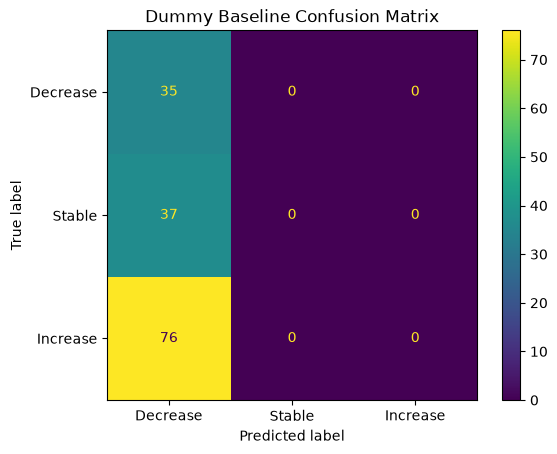

In [77]:
#Establishing my baseline model

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_results, dummy_predictions = (
    evaluate_classifier(
        "Dummy Baseline",
        dummy_model,
        X_train,
        X_test,
        y_train,
        y_test
    )
)


Model: Multinomial Logistic Regression
Accuracy: 0.351
Balanced Accuracy: 0.376
Macro F1: 0.305

Classification Report:
              precision    recall  f1-score   support

    Decrease       0.25      0.74      0.38        35
      Stable       0.50      0.08      0.14        37
    Increase       0.59      0.30      0.40        76

    accuracy                           0.35       148
   macro avg       0.45      0.38      0.31       148
weighted avg       0.49      0.35      0.33       148



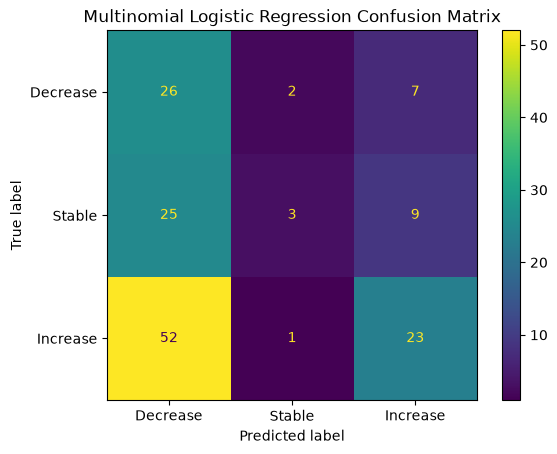

In [78]:
#Building my multinomial logistic regression, utilizing pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    
    (
        "scaler",
        StandardScaler()
    ),
    
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])


#Training and evaluating
logistic_results, logistic_predictions = (
    evaluate_classifier(
        "Multinomial Logistic Regression",
        logistic_model,
        X_train,
        X_test,
        y_train,
        y_test
    )
)


Model: Random Forest
Accuracy: 0.257
Balanced Accuracy: 0.266
Macro F1: 0.251

Classification Report:
              precision    recall  f1-score   support

    Decrease       0.16      0.40      0.23        35
      Stable       0.38      0.16      0.23        37
    Increase       0.38      0.24      0.29        76

    accuracy                           0.26       148
   macro avg       0.31      0.27      0.25       148
weighted avg       0.33      0.26      0.26       148



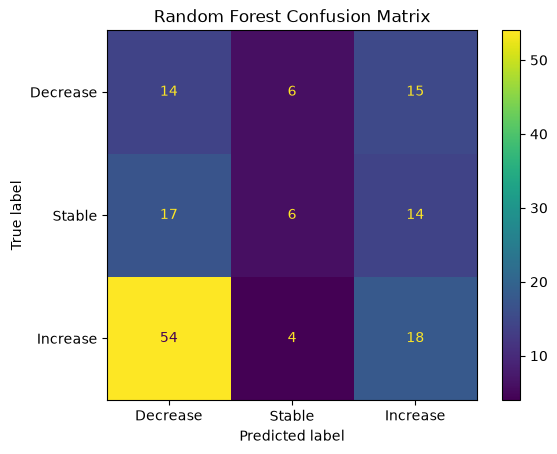

In [79]:
#Building a Random Forest classifier

random_forest_model = (
    RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )
)


#Evaluating 
rf_results, rf_predictions = (
    evaluate_classifier(
        "Random Forest",
        random_forest_model,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

In [80]:
#Comparing the models

model_comparison = pd.DataFrame([
    dummy_results,
    logistic_results,
    rf_results
])

display(
    model_comparison.sort_values(
        "Macro_F1",
        ascending=False
    )
)

,Model,Accuracy,Balanced_Accuracy,Macro_F1
1,Multinomial Logistic Regression,0.351351,0.375523,0.305449
2,Random Forest,0.256757,0.266335,0.250810
0,Dummy Baseline,0.236486,0.333333,0.127505


In [81]:
#Examining multinomial logistic coefficients

logistic_classifier = (
    logistic_model.named_steps[
        "classifier"
    ]
)

coefficient_table = pd.DataFrame(
    logistic_classifier.coef_.T,
    index=final_predictors,
    columns=
        logistic_classifier.classes_
)

display(
    coefficient_table
)

,Decrease,Increase,Stable
incarceration_rate,-0.027838,0.035356,-0.007518
murder_rate,-0.023694,0.113442,-0.089748
rape_rate,-0.024814,0.004054,0.020760
robbery_rate,0.291299,-0.569424,0.278125
aggravated_assault_rate,0.194154,-0.107668,-0.086486
burglary_rate,0.055175,-0.013559,-0.041616
larceny_rate,-0.036843,-0.106161,0.143005
vehicle_theft_rate,-0.206372,0.156866,0.049505


,Feature,Importance
3,robbery_rate,0.135339
7,vehicle_theft_rate,0.134251
4,aggravated_assault_rate,0.126384
1,murder_rate,0.122508
5,burglary_rate,0.122417
6,larceny_rate,0.121361
0,incarceration_rate,0.119199
2,rape_rate,0.118542


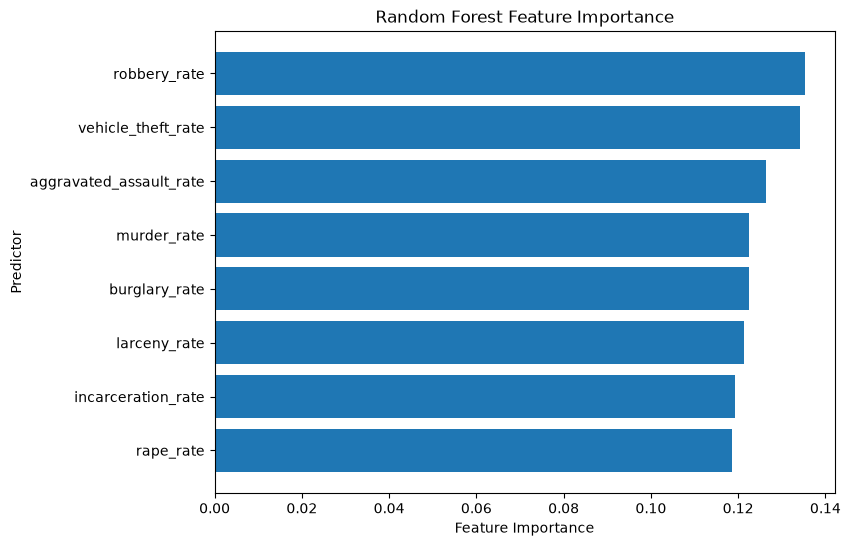

In [83]:
#Examining Random Forest feature importance with graph

feature_importance = pd.DataFrame({
    
    "Feature":
        final_predictors,
        
    "Importance":
        random_forest_model
        .feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance
)



#Graphing 
plt.figure(
    figsize=(8, 6)
)

plt.barh(
    feature_importance[
        "Feature"
    ],
    feature_importance[
        "Importance"
    ]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Predictor"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()